In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import pickle

In [ ]:
df = pd.read_csv('/content/Laptop_Dataset.csv')
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.873452,16,512,11.227538,2.682167,22453.49
1,Acer,2.919128,4,1000,11.344351,3.262293,15704.00
2,Lenovo,3.306839,4,256,11.980156,2.052301,11706.58
3,Acer,3.834458,16,512,12.300861,4.596167,21080.31
4,Acer,3.284636,32,1000,14.930983,4.162073,30471.45


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [ ]:
df.isnull().sum()

,0
Brand,0
Processor_Speed,0
RAM_Size,0
Storage_Capacity,0
Screen_Size,0
Weight,0
Price,0


In [ ]:
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.752854,15.500000,584.576000,14.054765,3.467700,19672.588600
std,0.733342,10.988665,313.438517,1.711058,0.865290,6246.771345
min,1.460457,4.000000,256.000000,10.948318,1.900000,8178.600000
25%,2.095669,8.000000,256.000000,12.602816,2.712187,14296.527500
50%,2.764445,16.000000,512.000000,14.111436,3.462165,19179.565000
75%,3.364706,32.000000,1000.000000,15.549837,4.201778,24053.337500
max,4.031118,32.000000,1000.000000,17.116574,5.061883,39702.460000


In [ ]:
df.duplicated().sum()

np.int64(0)

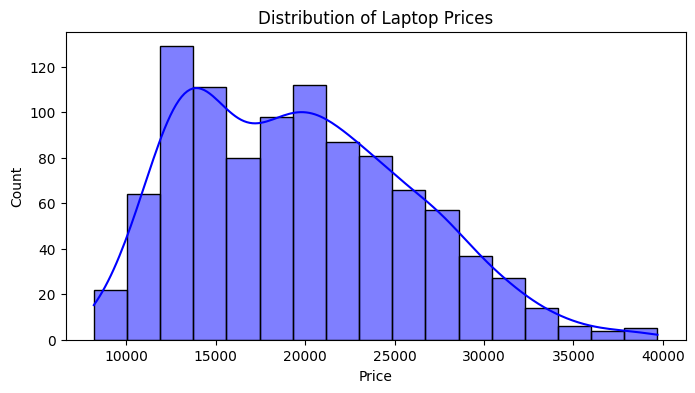

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Laptop Prices')
plt.show()

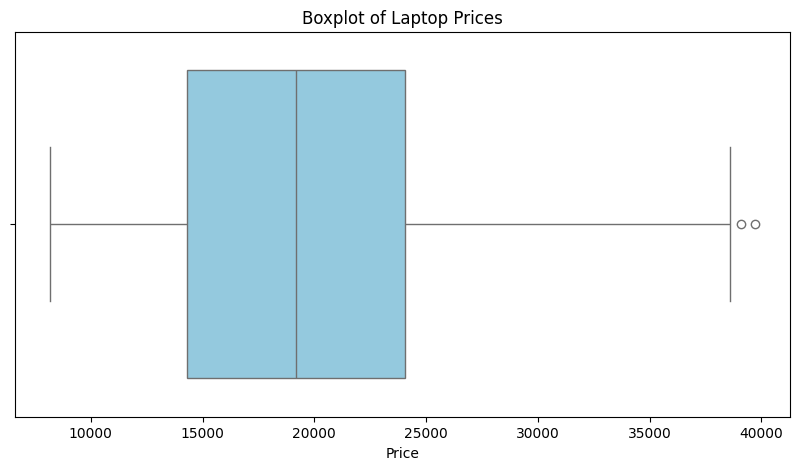

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Price'], color='skyblue')
plt.title('Boxplot of Laptop Prices')
plt.xlabel('Price')
plt.show()

In [ ]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Price'] < (Q1 - 1.5 * IQR)) | (df['Price'] > (Q3 + 1.5 * IQR)))]

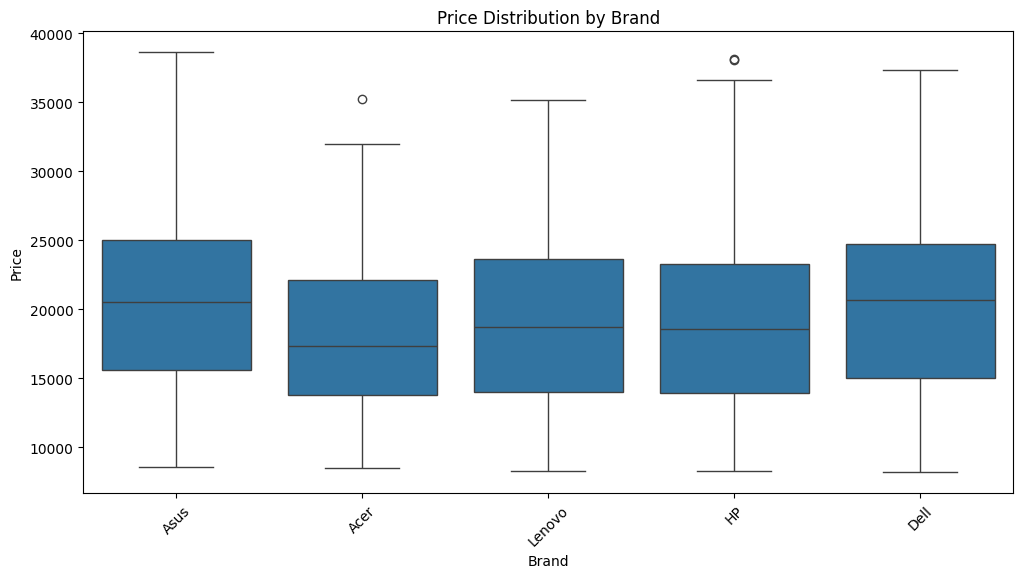

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df)
plt.title('Price Distribution by Brand')
plt.xticks(rotation=45)
plt.show()

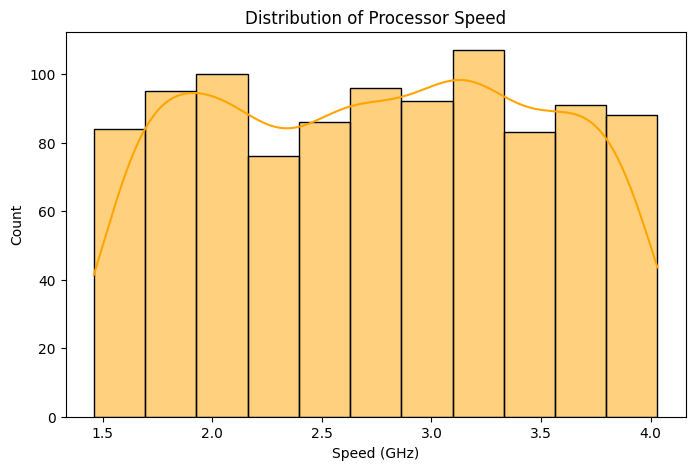

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Processor_Speed'], kde=True, color='orange')
plt.title('Distribution of Processor Speed')
plt.xlabel('Speed (GHz)')
plt.show()

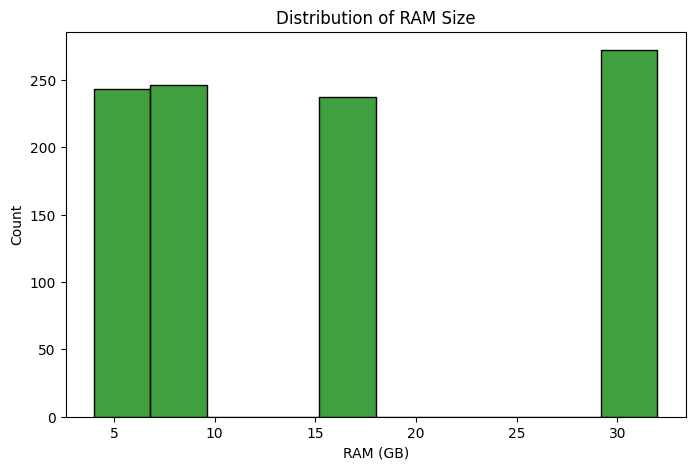

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['RAM_Size'], kde=False, bins=10, color='green')
plt.title('Distribution of RAM Size')
plt.xlabel('RAM (GB)')
plt.show()

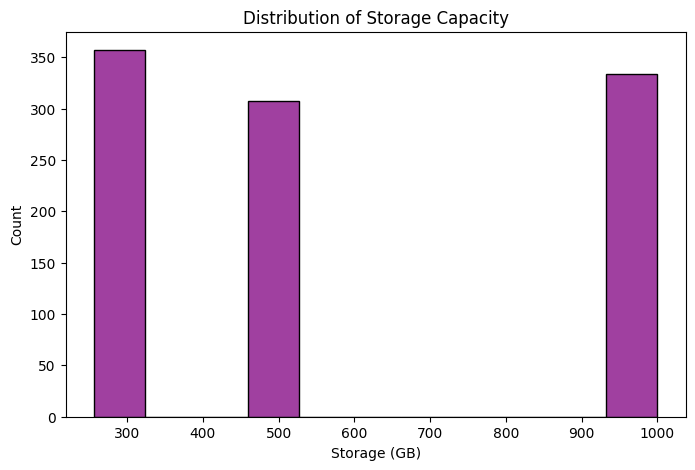

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Storage_Capacity'], kde=False, color='purple')
plt.title('Distribution of Storage Capacity')
plt.xlabel('Storage (GB)')
plt.show()

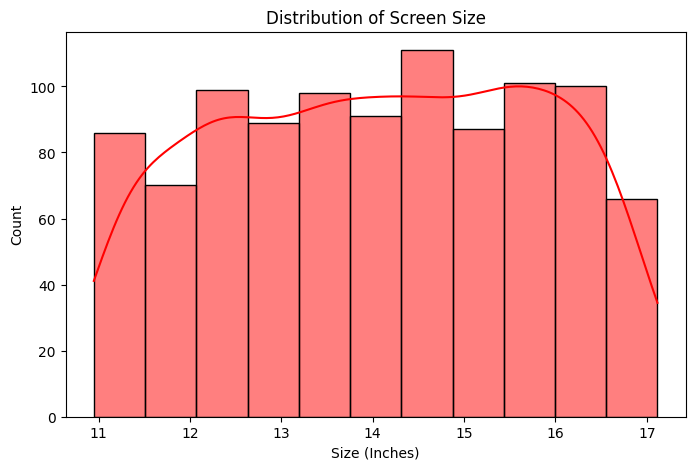

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Screen_Size'], kde=True, color='red')
plt.title('Distribution of Screen Size')
plt.xlabel('Size (Inches)')
plt.show()

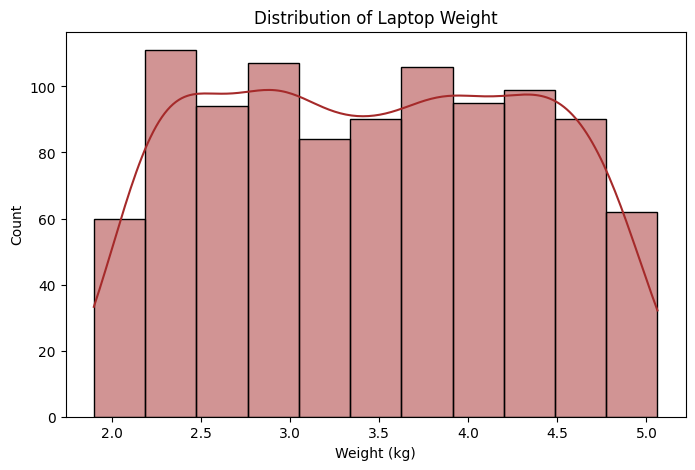

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Weight'], kde=True, color='brown')
plt.title('Distribution of Laptop Weight')
plt.xlabel('Weight (kg)')
plt.show()

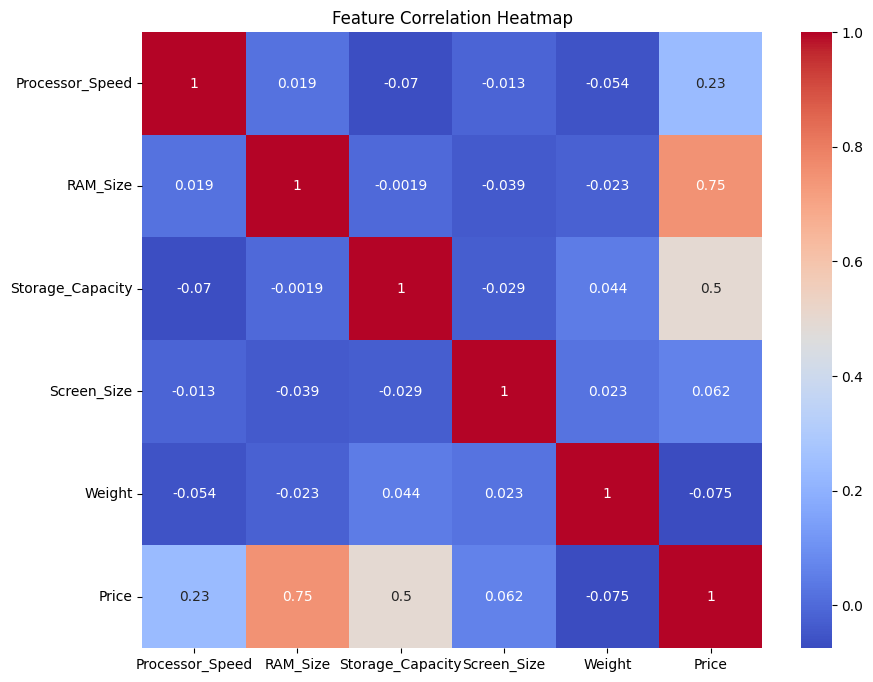

In [ ]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
df['Performance_Score'] = df['Processor_Speed'] * df['RAM_Size']

In [ ]:
df['Weight_per_Inch'] = df['Weight'] / df['Screen_Size']

In [ ]:
df

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price,Performance_Score,Weight_per_Inch
0,Asus,3.873452,16,512,11.227538,2.682167,22453.49,61.975232,0.238892
1,Acer,2.919128,4,1000,11.344351,3.262293,15704.00,11.676510,0.287570
2,Lenovo,3.306839,4,256,11.980156,2.052301,11706.58,13.227357,0.171308
3,Acer,3.834458,16,512,12.300861,4.596167,21080.31,61.351330,0.373646
4,Acer,3.284636,32,1000,14.930983,4.162073,30471.45,105.108358,0.278754
...,...,...,...,...,...,...,...,...,...
995,HP,3.295290,4,1000,12.697841,3.188351,18725.14,13.181160,0.251094
996,Dell,2.765903,8,256,12.649372,3.801175,15065.31,22.127227,0.300503
997,Dell,3.179885,4,512,12.630265,3.261647,15363.64,12.719540,0.258241
998,Asus,1.566333,8,256,11.298370,3.889352,10081.86,12.530662,0.344240


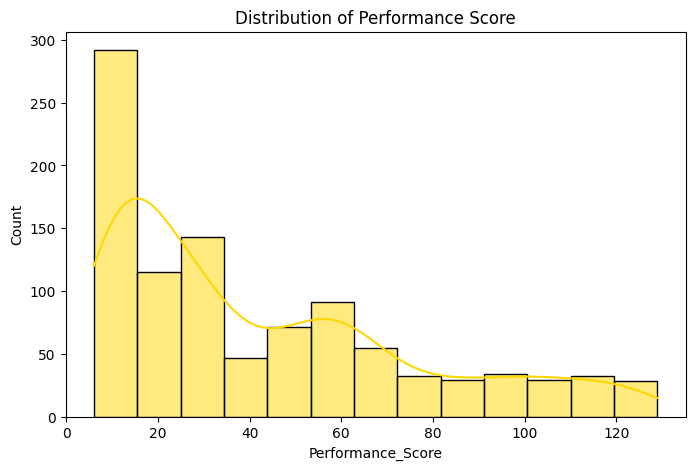

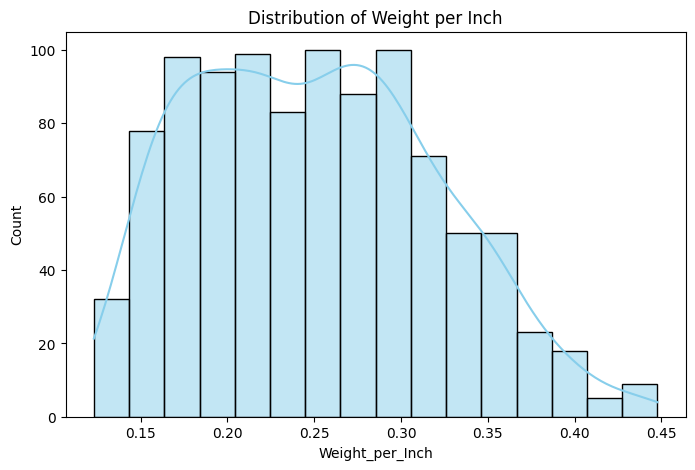

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Performance_Score'], kde=True, color='gold')
plt.title('Distribution of Performance Score')
plt.show()
print()
plt.figure(figsize=(8, 5))
sns.histplot(df['Weight_per_Inch'], kde=True, color='skyblue')
plt.title('Distribution of Weight per Inch')
plt.show()

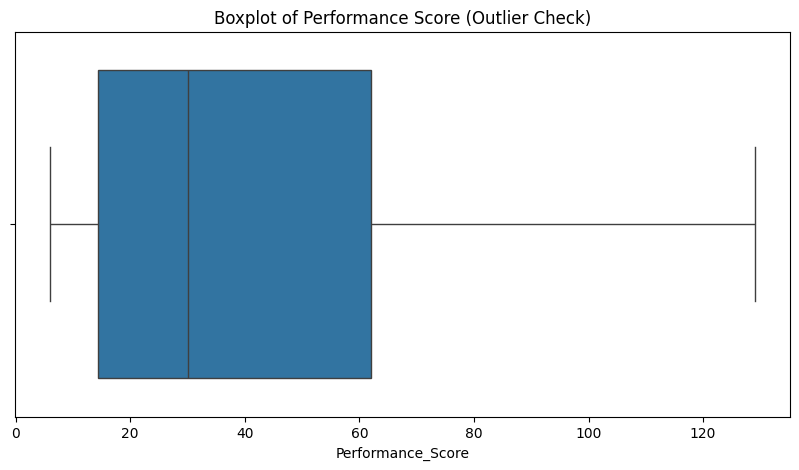

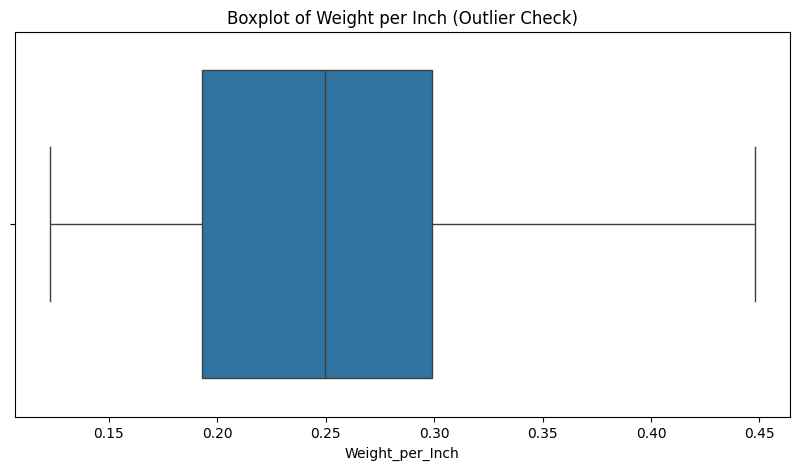

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Performance_Score'])
plt.title('Boxplot of Performance Score (Outlier Check)')
plt.show()
print()
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Weight_per_Inch'])
plt.title('Boxplot of Weight per Inch (Outlier Check)')
plt.show()

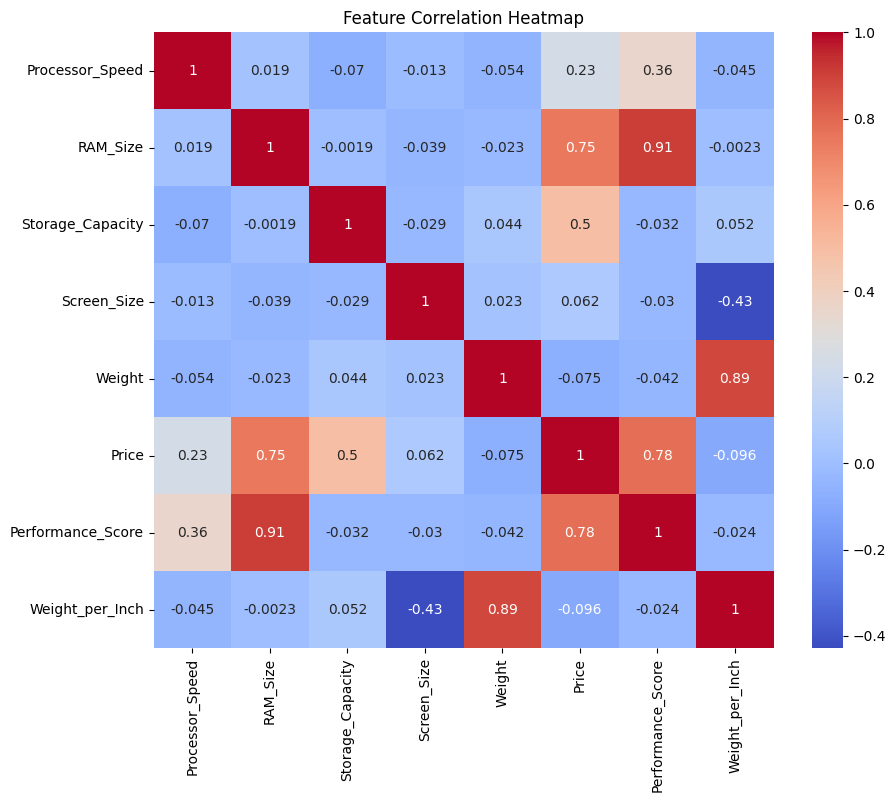

In [ ]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
le = LabelEncoder()
df['Brand'] = le.fit_transform(df['Brand'])
print(df.head())

   Brand  Processor_Speed  RAM_Size  Storage_Capacity  Screen_Size    Weight  \
0      1         3.873452        16               512    11.227538  2.682167   
1      0         2.919128         4              1000    11.344351  3.262293   
2      4         3.306839         4               256    11.980156  2.052301   
3      0         3.834458        16               512    12.300861  4.596167   
4      0         3.284636        32              1000    14.930983  4.162073   

      Price  Performance_Score  Weight_per_Inch  
0  22453.49          61.975232         0.238892  
1  15704.00          11.676510         0.287570  
2  11706.58          13.227357         0.171308  
3  21080.31          61.351330         0.373646  
4  30471.45         105.108358         0.278754  


In [ ]:
x = df.drop('Price', axis=1)
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Linear SVM": SVR(kernel='linear', C=100, epsilon=0.1),
    "RBF SVM": SVR(kernel='rbf', C=100, gamma=0.1),
    "Polynomial SVM": SVR(kernel='poly', C=100, degree=2),
    "Sigmoid SVM": SVR(kernel='sigmoid', C=100, gamma='scale')
}

In [ ]:
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results.append([name,mse,r2])

In [ ]:
result_df = pd.DataFrame(results,columns=['Model','MSE','R2'])
print(result_df)

                      Model           MSE        R2
0         Linear Regression  3.398074e+06  0.901149
1          Ridge Regression  3.395606e+06  0.901221
2          Lasso Regression  3.397775e+06  0.901157
3  Decision Tree Regression  6.617019e+06  0.807508
4  Random Forest Regression  3.248912e+06  0.905488
5       K-Nearest Neighbors  3.939935e+06  0.885386
6                Linear SVM  3.449764e+06  0.899645
7                   RBF SVM  9.147241e+06  0.733903
8            Polynomial SVM  2.848800e+07  0.171273
9               Sigmoid SVM  4.092594e+06  0.880945


## By Ensemble Learning

In [ ]:
models={
"Linear Regression":LinearRegression(),
"Ridge Regression":Ridge(),
"Lasso Regression":Lasso(),
"Decision Tree Regression":DecisionTreeRegressor(),
"Random Forest Regression":RandomForestRegressor(n_estimators=150),
"knn":KNeighborsRegressor(n_neighbors=5),
}

In [ ]:
from sklearn.ensemble import StackingRegressor
stack_model = StackingRegressor(
estimators=[
('lr', models['Linear Regression']),
('ridge', models['Ridge Regression']),
('lasso', models['Lasso Regression']),
('dt', models['Decision Tree Regression']),
('knn',models['knn'])
],

final_estimator=models['Random Forest Regression']
)
stack_model.fit(x_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()), ('ridge', Ridge()),
                              ('lasso', Lasso()),
                              ('dt', DecisionTreeRegressor()),
                              ('knn', KNeighborsRegressor())],
                  final_estimator=RandomForestRegressor(n_estimators=150))

In [ ]:
y_pred = stack_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
results.append(['Stacking',mse,r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")


MSE: 4010707.352168154
R2: 0.883327012883431


In [ ]:
from sklearn.ensemble import VotingRegressor

vote_model = VotingRegressor(
    estimators=[
        ('lr',models['Linear Regression']),
        ('ridge',models['Ridge Regression']),
        ('lasso',models['Lasso Regression']),
        ('dt',models['Decision Tree Regression']),
        ('knn',models['knn']),
        ('rf',models['Random Forest Regression'])
    ]
)

vote_model.fit(x_train,y_train)

VotingRegressor(estimators=[('lr', LinearRegression()), ('ridge', Ridge()),
                            ('lasso', Lasso()), ('dt', DecisionTreeRegressor()),
                            ('knn', KNeighborsRegressor()),
                            ('rf', RandomForestRegressor(n_estimators=150))])

In [ ]:
y_pred = vote_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
results.append(['Voting',mse,r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 2964670.834958988
R2: 0.9137566090567418


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results.append(['XGBoost', mse, r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 2843083.565216624
R2: 0.9172936285175411


In [ ]:
results_df = pd.DataFrame(results,columns=['Model','MSE','R2'])
print(results_df)

                       Model           MSE        R2
0          Linear Regression  3.398074e+06  0.901149
1           Ridge Regression  3.395606e+06  0.901221
2           Lasso Regression  3.397775e+06  0.901157
3   Decision Tree Regression  6.617019e+06  0.807508
4   Random Forest Regression  3.248912e+06  0.905488
5        K-Nearest Neighbors  3.939935e+06  0.885386
6                 Linear SVM  3.449764e+06  0.899645
7                    RBF SVM  9.147241e+06  0.733903
8             Polynomial SVM  2.848800e+07  0.171273
9                Sigmoid SVM  4.092594e+06  0.880945
10                  Stacking  4.010707e+06  0.883327
11                    Voting  2.964671e+06  0.913757
12                   XGBoost  2.843084e+06  0.917294


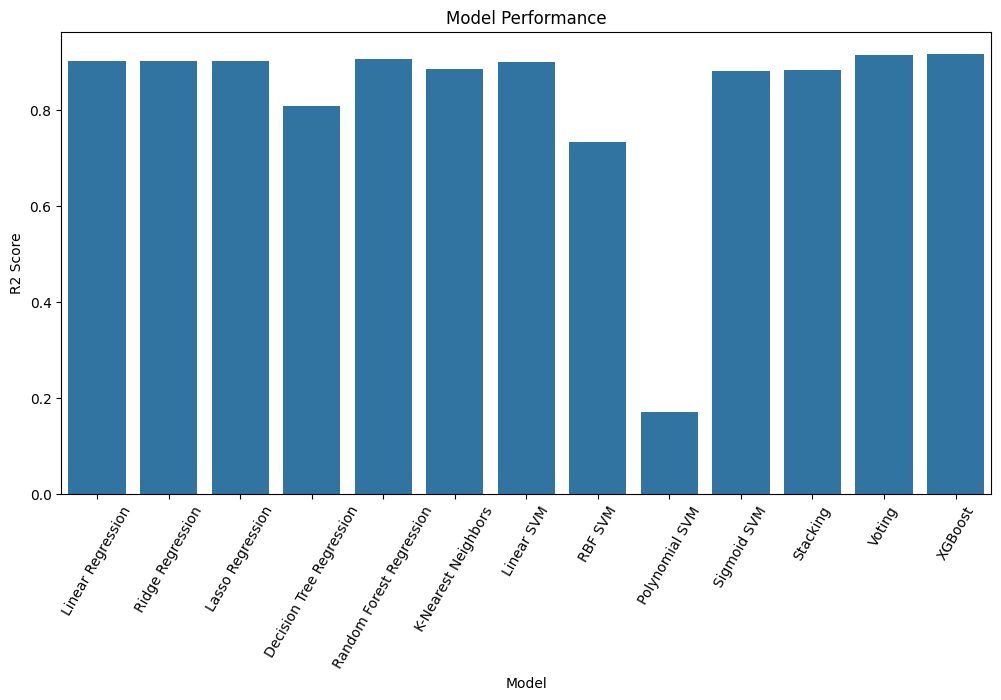

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2', data=results_df)
plt.title('Model Performance')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=60)
plt.show()

In [ ]:
best_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 2843083.565216624
R2 Score: 0.9172936285175411


##GUI

In [ ]:
pip install streamlit

In [ ]:
import pickle
with open('laptop_price_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

In [ ]:
import streamlit as st
import pandas as pd
import pickle

with open('laptop_price_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

st.set_page_config(page_title="Laptop Price Predictor", layout="centered")
st.title("Laptop Price Prediction Tool")

with st.form("prediction_form"):
    col1, col2 = st.columns(2)

    with col1:
        brand_name = st.selectbox('Brand', ['Acer', 'Asus', 'Dell', 'HP', 'Lenovo'])
        speed = st.number_input('Processor Speed (GHz)', value=2.5, step=0.1)
        ram = st.number_input('RAM Size (GB)', value=8, step=4)
        storage = st.number_input('Storage Capacity (GB)', value=512, step=128)

    with col2:
        screen = st.number_input('Screen Size (Inches)', value=15.6, step=0.1)
        weight = st.number_input('Weight (kg)', value=1.6, step=0.1)

    submit = st.form_submit_button("Predict Price")

if submit:
    mapping = {'Acer': 0, 'Asus': 1, 'Dell': 2, 'HP': 3, 'Lenovo': 4}
    brand = mapping[brand_name]

    perf_score = speed * ram
    weight_per_inch = weight / screen

    input_df = pd.DataFrame([[
        brand, speed, ram, storage, screen, weight, perf_score, weight_per_inch
    ]], columns=[
        'Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
        'Screen_Size', 'Weight', 'Performance_Score', 'Weight_per_Inch'
    ])

    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)
    final_price = float(prediction[0])

    st.success(f"### Estimated Price: ₹ {round(final_price, 2)}")

2026-04-06 21:37:32.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.810 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.847 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 21:37:32.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar